In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def make_plot(y_test, y_pred, name):
    fontsize = 28
    label_fontsize = 32
    tick_fontsize = 26
    
    fig, ax = plt.subplots(figsize=(10, 9))
    
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    metrics_text = f"R² = {r2:.3f}\nRMSE = {rmse:.1f}\nMAE = {mae:.1f}"
    
    plt.xlim(-5, 105)
    plt.ylim(-5, 105)
    
    plt.scatter(y_pred, y_test, alpha=0.4, color="#1f77b4", s=60)  # 调整点的大小和透明度
    
    plt.plot(np.arange(100), np.arange(100), ls="--", c=".3", linewidth=2)
    
    ax.text(0.05, 0.95, metrics_text, 
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=fontsize,
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
    
    ax.set_ylabel('True', fontsize=label_fontsize)
    ax.set_xlabel('Predicted', fontsize=label_fontsize)
    ax.set_title(name, fontsize=label_fontsize)  # 增加标题间距
    
    # 设置刻度标签大小
    plt.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    
    # 调整布局（确保标签不超出画布）
    plt.tight_layout()
    
    plt.show()

### test4

In [ ]:
from ChemBart import CB_Regression
import json
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

LABEL_NUM = 1

task_token = ["<n00>", "<n01>", "<n02>","<n03>", "<n04>"]
ends = "".join(task_token[:LABEL_NUM - 1]) + "<end>"
c = CB_Regression(name = "BH_test4", pre_model='ChemBart_MIT_9',label_num = LABEL_NUM, device = "cuda:2") #"cuda:0", "cuda:1" etc.
with open("data/yield/bh_C_N_yield/MFF_Test4/train.json") as f:
    l = json.load(f)
for i in range(len(l)):
    l[i][0] += ends
print(l[1])

train_prop = 6/7
valid_prop = 1/7

train_size = int(train_prop*len(l))
valid_size = int(valid_prop*len(l))
test_size = 0

labels = [item[1] for item in l]

train_labels = labels[:train_size]
mean = np.mean(train_labels)
std = np.std(train_labels)

standardized_labels = [(label - mean) / std for label in labels]

for i, item in enumerate(l):
    l[i][1] = [float(standardized_labels[i])]
print(l[1])

c.fit(data = l[0:train_size+valid_size], epoch = 1000, batch_size = 8, tr=train_size, val=valid_size, te = test_size ,lr=1e-5,decay=1e-5,id_maxlen=512)

#test
with open("data/yield/bh_C_N_yield/MFF_Test4/test.json") as f:
    test = json.load(f)
for i in range(len(test)):
    test[i][0] += ends

test_labels = [item[1] for item in test]
standardized_labels = [(label - mean) / std for label in test_labels]
for i, item in enumerate(test):
    test[i][1] = [float(standardized_labels[i])]
    
c = CB_Regression(name = "BH_test4", pre_model='ChemBart_MIT_9',label_num = LABEL_NUM, device = "cuda:2") #"cuda:0", "cuda:1" etc.
(RMSE_list, reslist) = c.test(test, batch_size = 4)

y_pred, y_test = [], []
for sublist in reslist:
    if all(isinstance(item, tuple) and len(item) == 2 for item in sublist):
        y_pred.extend([(item[0] * std + mean)*100 for item in sublist])
        y_pred = np.clip(y_pred, 0, 100)
        y_test.extend([(item[1] * std + mean)*100 for item in sublist])
    else:
        raise ValueError("Each element in sublist must be a tuple of length 2.")


pre-trained model ChemBart_model/ChemBart_MIT_9.pth
['FC(F)(F)c1ccc(Br)cc1.Cc1ccc(N)cc1>CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1.Nc1ccccc1-c1ccccc1[Pd]OS(=O)(=O)C(F)(F)F.c1ccc(-c2ccno2)cc1.CCN=P(N=P(N(C)C)(N(C)C)N(C)C)(N(C)C)N(C)C.CS(C)=O>Cc1ccc(Nc2ccc(C(F)(F)F)cc2)cc1<end>', [0.1475]]
['FC(F)(F)c1ccc(Br)cc1.Cc1ccc(N)cc1>CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1.Nc1ccccc1-c1ccccc1[Pd]OS(=O)(=O)C(F)(F)F.c1ccc(-c2ccno2)cc1.CCN=P(N=P(N(C)C)(N(C)C)N(C)C)(N(C)C)N(C)C.CS(C)=O>Cc1ccc(Nc2ccc(C(F)(F)F)cc2)cc1<end>', [-0.663687526194407]]
epoch 0
train
regression task 0 : rmse = 0.7175752324997878
train loss: 168.6416806690395
validation
regression task 0 : rmse = 0.6800307713811964
model refreshed!
epoch 1
train
regression task 0 : rmse = 0.49255559487929695
train loss: 80.50008580088615
validation
regression task 0 : rmse = 0.31360388254001786
model refreshed!
epoch 2
train
regression task 0 : rmse = 0.4714432327663353
train loss: 72.74861602298915
validation
r

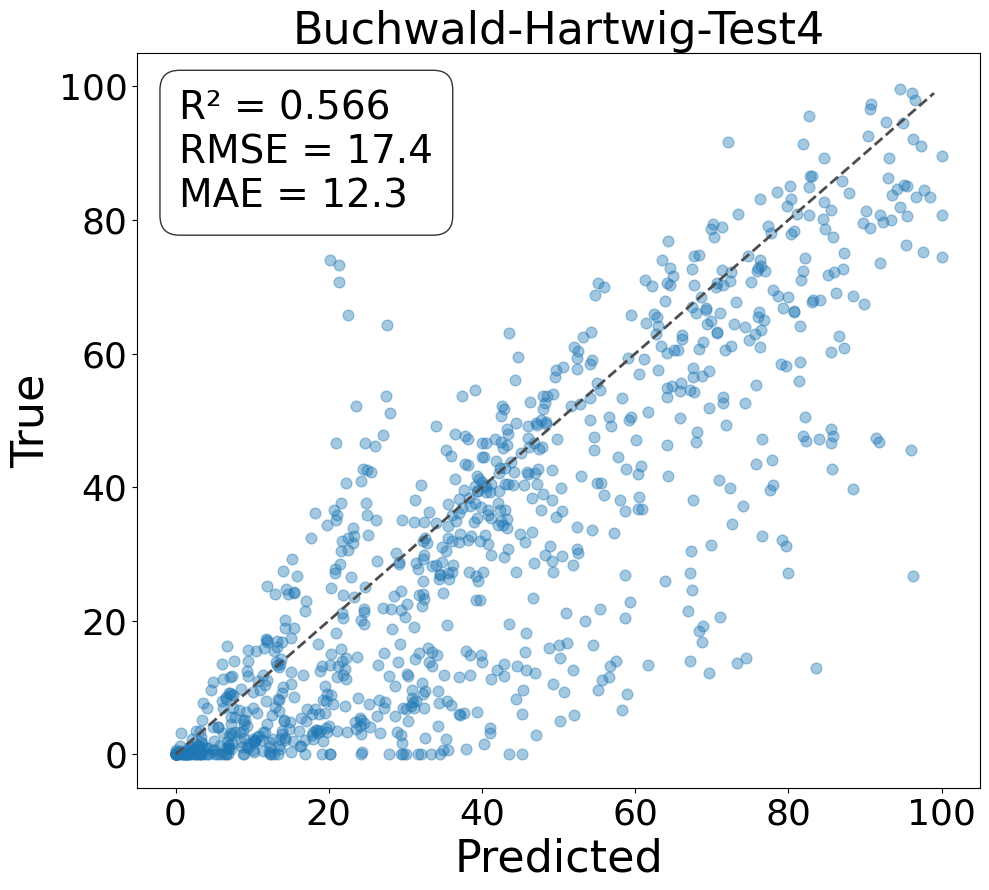

In [8]:
plot = make_plot(y_test, y_pred, 'Buchwald-Hartwig-Test4')